<a href="https://colab.research.google.com/github/AadityaBhure/Deep-Learning-Lab---7th-Semester/blob/main/prac9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install -q tensorflow scikit-learn seqeval

In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, TimeDistributed, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from seqeval.metrics import classification_report, f1_score

In [20]:
!git clone https://github.com/BrownFortress/IntentSlotDatasets.git

fatal: destination path 'IntentSlotDatasets' already exists and is not an empty directory.


In [21]:
!find IntentSlotDatasets/ATIS -type f

IntentSlotDatasets/ATIS/original/atis.test.ctf
IntentSlotDatasets/ATIS/original/atis.train.ctf
IntentSlotDatasets/ATIS/test.json
IntentSlotDatasets/ATIS/train.json


In [22]:
with open("IntentSlotDatasets/ATIS/train.json", "r") as f:
    train_data = json.load(f)

with open("IntentSlotDatasets/ATIS/test.json", "r") as f:
    test_data = json.load(f)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

print("\nFirst training example:")
print(train_data[0])

Training samples: 4978
Testing samples: 893

First training example:
{'utterance': 'i want to fly from boston at 838 am and arrive in denver at 1110 in the morning', 'slots': 'O O O O O B-fromloc.city_name O B-depart_time.time I-depart_time.time O O O B-toloc.city_name O B-arrive_time.time O O B-arrive_time.period_of_day', 'intent': 'flight'}


In [23]:
X_train_text = [item["utterance"].lower().split() for item in train_data]
y_train_text = [item["slots"].split() for item in train_data]

X_test_text = [item["utterance"].lower().split() for item in test_data]
y_test_text = [item["slots"].split() for item in test_data]

print("Sentence:")
print(X_train_text[0])

print("\nSlot Labels:")
print(y_train_text[0])

Sentence:
['i', 'want', 'to', 'fly', 'from', 'boston', 'at', '838', 'am', 'and', 'arrive', 'in', 'denver', 'at', '1110', 'in', 'the', 'morning']

Slot Labels:
['O', 'O', 'O', 'O', 'O', 'B-fromloc.city_name', 'O', 'B-depart_time.time', 'I-depart_time.time', 'O', 'O', 'O', 'B-toloc.city_name', 'O', 'B-arrive_time.time', 'O', 'O', 'B-arrive_time.period_of_day']


In [24]:
for words, labels in zip(X_train_text, y_train_text):
    assert len(words) == len(labels), "Mismatch found!"

for words, labels in zip(X_test_text, y_test_text):
    assert len(words) == len(labels), "Mismatch found!"

print("All words and slot labels are correctly aligned!")

All words and slot labels are correctly aligned!


In [25]:
tokenizer = Tokenizer(oov_token="<OOV>")

tokenizer.fit_on_texts(
    [" ".join(sentence) for sentence in X_train_text]
)

word_index = tokenizer.word_index

VOCAB_SIZE = len(word_index) + 1

print("Vocabulary Size:", VOCAB_SIZE)

Vocabulary Size: 891


In [26]:
X_train_sequences = tokenizer.texts_to_sequences(
    [" ".join(sentence) for sentence in X_train_text]
)

X_test_sequences = tokenizer.texts_to_sequences(
    [" ".join(sentence) for sentence in X_test_text]
)

print(X_train_text[0])
print(X_train_sequences[0])

['i', 'want', 'to', 'fly', 'from', 'boston', 'at', '838', 'am', 'and', 'arrive', 'in', 'denver', 'at', '1110', 'in', 'the', 'morning']
[13, 71, 2, 39, 3, 10, 69, 407, 87, 18, 80, 17, 14, 69, 531, 17, 5, 37]


In [27]:
MAX_LEN = max(
    max(len(sentence) for sentence in X_train_sequences),
    max(len(sentence) for sentence in X_test_sequences)
)

print("Maximum sentence length:", MAX_LEN)

Maximum sentence length: 46


In [28]:
X_train = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding="post"
)

X_test = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding="post"
)

print(X_train.shape)
print(X_test.shape)

(4978, 46)
(893, 46)


In [29]:
# Get all unique slot labels from BOTH training and testing data

all_labels = sorted(
    set(
        label
        for sentence_labels in (y_train_text + y_test_text)
        for label in sentence_labels
    )
)

# Padding label
PAD_LABEL_ID = 0

# Create label mappings
label_to_id = {
    label: idx + 1
    for idx, label in enumerate(all_labels)
}

id_to_label = {
    idx: label
    for label, idx in label_to_id.items()
}

# Number of output classes (+1 for padding)
NUM_LABELS = len(all_labels) + 1

print("Number of slot labels:", len(all_labels))
print("Total output classes:", NUM_LABELS)

print("\nAll slot labels:")
print(all_labels)

Number of slot labels: 129
Total output classes: 130

All slot labels:
['B-aircraft_code', 'B-airline_code', 'B-airline_name', 'B-airport_code', 'B-airport_name', 'B-arrive_date.date_relative', 'B-arrive_date.day_name', 'B-arrive_date.day_number', 'B-arrive_date.month_name', 'B-arrive_date.today_relative', 'B-arrive_time.end_time', 'B-arrive_time.period_mod', 'B-arrive_time.period_of_day', 'B-arrive_time.start_time', 'B-arrive_time.time', 'B-arrive_time.time_relative', 'B-booking_class', 'B-city_name', 'B-class_type', 'B-compartment', 'B-connect', 'B-cost_relative', 'B-day_name', 'B-day_number', 'B-days_code', 'B-depart_date.date_relative', 'B-depart_date.day_name', 'B-depart_date.day_number', 'B-depart_date.month_name', 'B-depart_date.today_relative', 'B-depart_date.year', 'B-depart_time.end_time', 'B-depart_time.period_mod', 'B-depart_time.period_of_day', 'B-depart_time.start_time', 'B-depart_time.time', 'B-depart_time.time_relative', 'B-economy', 'B-fare_amount', 'B-fare_basis_code'

In [30]:
y_train_sequences = [
    [label_to_id[label] for label in sentence]
    for sentence in y_train_text
]

y_test_sequences = [
    [label_to_id[label] for label in sentence]
    for sentence in y_test_text
]

print("Training example:")
print(y_train_text[0])
print(y_train_sequences[0])

print("\nTest example:")
print(y_test_text[0])
print(y_test_sequences[0])

Training example:
['O', 'O', 'O', 'O', 'O', 'B-fromloc.city_name', 'O', 'B-depart_time.time', 'I-depart_time.time', 'O', 'O', 'O', 'B-toloc.city_name', 'O', 'B-arrive_time.time', 'O', 'O', 'B-arrive_time.period_of_day']
[129, 129, 129, 129, 129, 49, 129, 36, 101, 129, 129, 129, 79, 129, 15, 129, 129, 13]

Test example:
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-fromloc.city_name', 'O', 'B-toloc.city_name', 'I-toloc.city_name', 'O', 'O', 'O', 'O', 'O', 'B-stoploc.city_name', 'I-stoploc.city_name']
[129, 129, 129, 129, 129, 129, 129, 129, 49, 129, 79, 126, 129, 129, 129, 129, 129, 72, 122]


In [31]:
y_train = pad_sequences(
    y_train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    value=PAD_LABEL_ID
)

y_test = pad_sequences(
    y_test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    value=PAD_LABEL_ID
)

print(y_train.shape)
print(y_test.shape)

(4978, 46)
(893, 46)


In [32]:
y_train_cat = to_categorical(
    y_train,
    num_classes=NUM_LABELS
)

y_test_cat = to_categorical(
    y_test,
    num_classes=NUM_LABELS
)

print(y_train_cat.shape)

(4978, 46, 130)


In [33]:
EMBEDDING_DIM = 128
LSTM_UNITS = 128

model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    LSTM(
        LSTM_UNITS,
        return_sequences=True
    ),

    Dropout(0.3),

    TimeDistributed(
        Dense(
            NUM_LABELS,
            activation="softmax"
        )
    )
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - accuracy: 0.6886 - loss: 1.9175 - val_accuracy: 0.7940 - val_loss: 1.0029
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - accuracy: 0.8215 - loss: 0.8062 - val_accuracy: 0.8530 - val_loss: 0.6476
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - accuracy: 0.8861 - loss: 0.5358 - val_accuracy: 0.9154 - val_loss: 0.4239
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - accuracy: 0.9228 - loss: 0.3625 - val_accuracy: 0.9395 - val_loss: 0.3008
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - accuracy: 0.9448 - loss: 0.2608 - val_accuracy: 0.9537 - val_loss: 0.2272
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - accuracy: 0.9595 - loss: 0.1962 - val_accuracy: 0.9633 - val_loss: 0.1853
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.9687 - loss: 0.1538 - val_accuracy: 0.9688 - val_loss: 0.1583
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 127ms/step - accuracy: 0.9749 - loss: 0

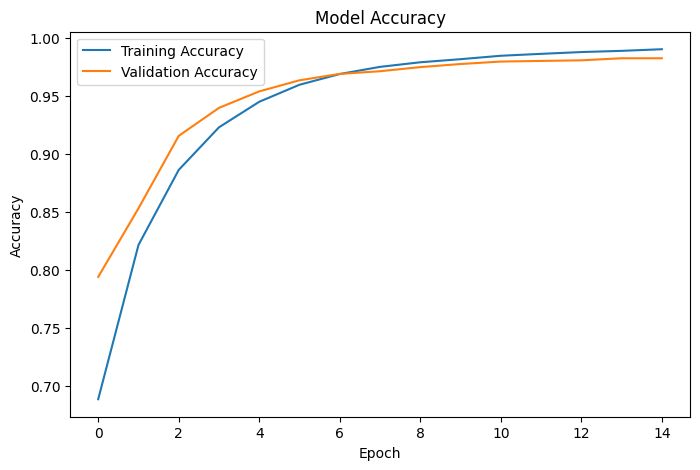

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

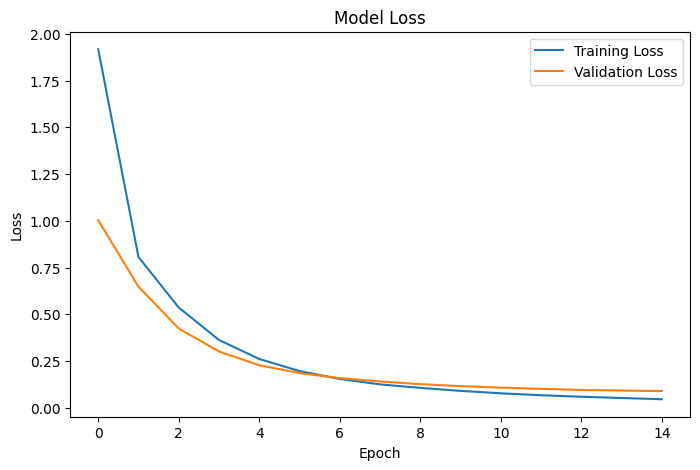

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [37]:
loss, accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.14342989027500153
Test Accuracy: 0.9698846340179443


In [38]:
predictions = model.predict(X_test)

predicted_ids = np.argmax(predictions, axis=-1)

print(predicted_ids.shape)

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step
(893, 46)


In [39]:
true_labels = []
pred_labels = []

for true_seq, pred_seq in zip(y_test, predicted_ids):

    for true_id, pred_id in zip(true_seq, pred_seq):

        if true_id != PAD_LABEL_ID:

            true_labels.append(true_id)
            pred_labels.append(pred_id)

token_accuracy = accuracy_score(
    true_labels,
    pred_labels
)

print("Token-Level Accuracy:", token_accuracy)

Token-Level Accuracy: 0.9698847575559905


In [40]:
true_sequences = []
pred_sequences = []

for true_seq, pred_seq in zip(y_test, predicted_ids):

    sentence_true = []
    sentence_pred = []

    for true_id, pred_id in zip(true_seq, pred_seq):

        if true_id != PAD_LABEL_ID:

            sentence_true.append(
                id_to_label[true_id]
            )

            sentence_pred.append(
                id_to_label[pred_id]
            )

    true_sequences.append(sentence_true)
    pred_sequences.append(sentence_pred)


f1 = f1_score(
    true_sequences,
    pred_sequences
)

print("Slot Filling F1 Score:", f1)

Slot Filling F1 Score: 0.9218063609207521


In [41]:
print(
    classification_report(
        true_sequences,
        pred_sequences
    )
)

                            precision    recall  f1-score   support

             aircraft_code       1.00      0.67      0.80        33
              airline_code       1.00      0.53      0.69        34
              airline_name       0.89      0.97      0.93       101
              airport_code       0.50      0.11      0.18         9
              airport_name       0.05      0.05      0.05        21
 arrive_date.date_relative       1.00      0.50      0.67         2
      arrive_date.day_name       0.79      1.00      0.88        11
    arrive_date.day_number       0.71      0.83      0.77         6
    arrive_date.month_name       0.62      0.83      0.71         6
      arrive_time.end_time       0.88      0.88      0.88         8
 arrive_time.period_of_day       0.71      0.83      0.77         6
    arrive_time.start_time       1.00      1.00      1.00         8
          arrive_time.time       0.91      0.94      0.93        34
 arrive_time.time_relative       0.84      0.87

/usr/local/lib/python3.13/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [42]:
def predict_slots(sentence):

    words = sentence.lower().split()

    sequence = tokenizer.texts_to_sequences(
        [" ".join(words)]
    )

    sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post"
    )

    prediction = model.predict(
        sequence,
        verbose=0
    )

    prediction = np.argmax(
        prediction,
        axis=-1
    )[0]

    predicted_labels = [
        id_to_label.get(
            prediction[i],
            "O"
        )
        for i in range(len(words))
    ]

    return words, predicted_labels

In [43]:
sentence = "show me flights from boston to new york"

words, slots = predict_slots(sentence)

print("Sentence:", sentence)

print("\nPredictions:")

for word, slot in zip(words, slots):
    print(f"{word:15} → {slot}")

Sentence: show me flights from boston to new york

Predictions:
show            → O
me              → O
flights         → O
from            → O
boston          → B-fromloc.city_name
to              → O
new             → B-toloc.city_name
york            → I-toloc.city_name


In [44]:
sentence = "i want a flight from chicago to dallas"

words, slots = predict_slots(sentence)

results = pd.DataFrame({
    "Word": words,
    "Predicted Slot": slots
})

results

,Word,Predicted Slot
0,i,O
1,want,O
2,a,O
3,flight,O
4,from,O
5,chicago,B-fromloc.city_name
6,to,O
7,dallas,B-toloc.city_name
